# TSMOM Terminal — Walkthrough del dashboard

**Ingeniería Financiera (F414) · UdeSA · TP final — Trend Following / Time Series Momentum**

Este notebook recorre el dashboard **sección por sección** para entender y justificar todo lo que hicimos.
La idea es que cada página del dashboard (`src/dashboard/app.py`) tenga acá su explicación con:

- **qué muestra** la página,
- **qué función del backend** (`src/`) la alimenta,
- la **teoría / fórmula** detrás (con el paper que la fundamenta), y
- una **celda de código** que reproduce el número usando el mismo backend real.

> El dashboard es solo una *capa de presentación*: todos los números salen de `src/`. Acá llamamos
> exactamente las mismas funciones, así que lo que veas acá es idéntico a lo que muestra la terminal.

**Papers que fundamentan la estrategia**

| Rol | Paper | Qué aporta |
|-----|-------|------------|
| Principal `[L]` | Moskowitz, Ooi & Pedersen (2012) — *Time Series Momentum* | la señal de signo, la normalización por volatilidad ex-ante, el target-vol por activo, el rebalanceo mensual |
| Complementario `[H]` | Baz et al. (2015) — *Dissecting Investment Strategies* | la señal **continua** (strength) normalizada, y el multi-horizonte |
| Adicional | Daniel & Moskowitz (2016) — *Momentum Crashes* | el **filtro de crash** (recortar exposición en regímenes de pánico) |
| Adicional | Moreira & Muir (2017) — *Volatility-Managed Portfolios* | el **vol-scaling del portafolio** (escalar la cartera entera al target de riesgo) |

---
### Cómo correr este notebook
Usar el kernel del env **`finance`** (Python 3.13, pandas ≥ 2.2). El `python3`/anaconda base es 3.11 y
**rompe** el loader por la frecuencia `"ME"`. Desde la terminal:
```bash
conda activate finance
jupyter lab dashboard_walkthrough.ipynb   # correr desde la raíz del proyecto (TP/)
```

## Setup — cargamos el backend real una sola vez

In [1]:
import yaml
import numpy as np
import pandas as pd
pd.set_option('display.precision', 4)

# --- backend real del proyecto (las mismas funciones que usa el dashboard) ---
from src.data.loader import load_returns
from src.data.universe import ETF_UNIVERSE, ASSET_CLASSES
from src.strategy.signals import compute_tsmom_signal, compute_signal_strength
from src.strategy.volatility import compute_ex_ante_vol
from src.strategy.portfolio import (
    compute_vol_scaled_weights, compute_classbalanced_weights, build_portfolio,
)
from src.backtest.engine import BacktestEngine
from src.backtest.metrics import (
    sharpe_ratio, annualized_return, annualized_volatility, max_drawdown, calmar_ratio,
)
from src.robustness.sensitivity import optimize_sharpe

config  = yaml.safe_load(open('config.yaml'))
returns = load_returns(config)   # retornos MENSUALES de los ETF del universo activo

# IMPORTANTE — reproducimos el estado "al abrir el dashboard".
# La terminal, al cargar, corre optimize_sharpe (grid 3-24m x 5-40%) para la señal/ponderación
# elegidas y FIJA los sliders al óptimo in-sample. Todos los Sharpes que mostramos/comparamos en
# este notebook usan ESE óptimo (no el 12m/10% que el config.yaml guarda como base).
opt, _ = optimize_sharpe(returns, config)          # combo por defecto: strength | pooled
config['strategy']['lookback_months']   = opt['lookback']
config['strategy']['target_volatility'] = opt['target_vol']

print(f"Universo activo : {returns.shape[1]} ETFs")
print(f"Ventana         : {returns.index[0].date()}  ->  {returns.index[-1].date()}  ({len(returns)} meses)")
print(f"Óptimo (strength|pooled): Sharpe {opt['sharpe']:.3f}  @ lookback {opt['lookback']}m · target vol {opt['target_vol']*100:.0f}%")
config['strategy']

Universo activo : 133 ETFs
Ventana         : 2012-02-29  ->  2026-05-31  (172 meses)
Óptimo (strength|pooled): Sharpe 0.896  @ lookback 17m · target vol 17%


{'lookback_months': 17,
 'target_volatility': 0.17,
 'rebalancing': 'monthly',
 'max_position_weight': 0.15,
 'vol_com_months': 3,
 'signal_mode': 'strength',
 'lookbacks': [3, 6, 12],
 'weighting': 'pooled',
 'use_crash_filter': True,
 'use_portfolio_vol_scaling': True,
 'target_portfolio_vol': 0.07}

---
# 00 · Selección del universo

> **El planteo.** Antes de cualquier señal hay que decidir **qué ETFs entran y cuáles no**. Esa decisión
> condiciona todo lo que sigue (la señal, la ponderación, el riesgo del portafolio), así que conviene tenerla
> documentada y poder justificarla. La idea: un universo **amplio** (muchas clases y mercados, para que el
> TSMOM diversifique de verdad) pero **operable y sin redundancias** (que represente mercados *distintos*, no
> el mismo índice diez veces).

Partimos de un universo **crudo de 205 ETFs** y lo curamos hasta **133 mercados distintos**, con tres reglas.
La fuente de verdad es `src/data/universe.py` (la celda de abajo reproduce los números).

### Regla 1 — Solo US-listed en USD
Todos los ETFs cotizan en EE.UU. y en dólares. **No** entran ETFs extranjeros (`.MI` de Milán, `.TO` de
Toronto, etc.): sus retornos mezclan el movimiento del activo con el del tipo de cambio (EUR/CAD vs USD), lo
que **contamina** una estrategia 100% en USD. Esos quedan registrados en `EXCLUDED_TICKERS` con el motivo.

### Regla 2 — Cada ETF desde su *inception*, sin lookahead
Se incluye un ETF **sin importar cuándo arrancó**: se usa desde que existe, y los meses previos quedan `NaN`
(el pipeline los trata como "activo inactivo", peso 0). Así evitamos *survivorship bias* (no descartamos lo
que arrancó tarde) y *lookahead bias* (nunca usamos un activo antes de que existiera). El único requisito es
tener historia mínima para formar señal (`data.min_history_months` en `config.yaml`).

### Regla 3 — Curación por liquidez (corr ≥ 0.95) → 1 instrumento por *mercado*
Acá está el punto fino. Siguiendo a **Moskowitz et al. (2012)** —que usa **un instrumento líquido por
mercado**— agrupamos los ETFs por **correlación de retornos mensuales** (complete-linkage, **corr ≥ 0.95** =
"el mismo mercado") y nos quedamos con **el más líquido** de cada grupo (mayor dollar-volume). Los **72**
redundantes van a `REDUNDANT_TICKERS`, cada uno con el ticker que lo reemplaza. Así pasamos de **205 → 133**.

> ⚠️ **"Mismo mercado" ≠ "mismo sector/clase".** El cluster junta *clones del mismo índice*, no clases de
> activo. Por ejemplo, `SPY` absorbe a `IVV, VOO, VTI, ITOT, IWB, OEF, QUAL` (todos S&P 500 / total-US, corr
> > 0.95); `GLD` absorbe `IAU, SGOL`; `EEM` absorbe `IEMG, VWO`. Lo que se saca son **duplicados** del mismo
> mercado, **no** diversidad entre clases.

### Consecuencia (clave para `pooled` vs `class_balanced`, sección B)
La curación **no** dejó "un ETF por clase": el universo activo sigue **muy sesgado a equity** (~89 de 133
nombres ≈ 67%; ver celda). Por eso las dos ponderaciones de la sección B son **genuinamente distintas**:
`pooled` (1/N global) deja que equity —con muchos más nombres— domine el riesgo, mientras que
`class_balanced` reparte el presupuesto parejo entre las 4 clases. **Solo** serían idénticas si hubiéramos
colapsado a *un único ETF por clase* (4 en total), y eso **no** se hizo: curamos por *redundancia de mercado*,
no por sector.

> Scripts de soporte: `scripts/universe_redundancy.py` arma los clusters de correlación;
> `scripts/compare_universe_backtest.py` compara el backtest con 205 vs 133; `python main.py data-status`
> chequea que `universe.py` y `Data/etf_prices.parquet` sigan alineados. Para volver a los 205, basta vaciar
> `REDUNDANT_TICKERS` (los datos siguen en el parquet).

In [ ]:
# --- Selección del universo: de 205 ETFs crudos a 133 mercados distintos ---
from collections import Counter
from src.data.universe import _ALL_ETFS, ETF_UNIVERSE, REDUNDANT_TICKERS, EXCLUDED_TICKERS

print(f"Universo CRUDO   : {len(_ALL_ETFS)} ETFs US-listed en USD")
print(f"Redundantes      : -{len(REDUNDANT_TICKERS)}  (corr >= 0.95, se queda el más líquido de cada grupo)")
print(f"Excluidos a mano : -{len(EXCLUDED_TICKERS)}  (.MI/.TO en EUR/CAD: ruido de FX)")
print(f"Universo ACTIVO  : {len(ETF_UNIVERSE)} mercados distintos\n")

crudo  = Counter(_ALL_ETFS.values())
activo = Counter(ETF_UNIVERSE.values())
tabla = pd.DataFrame({'crudo (205)': crudo, 'activo (133)': activo}).reindex(
    ['equity', 'bond', 'commodity', 'currency'])
tabla['% nombres (activo)'] = (tabla['activo (133)'] / tabla['activo (133)'].sum() * 100).round(1)
print("Composición por clase de activo:")
print(tabla.to_string())

# Ejemplo de UN cluster de liquidez: 'mismo mercado' (corr >= 0.95), NO 'mismo sector'
spy_cluster = sorted(t for t, v in REDUNDANT_TICKERS.items() if 'SPY' in v)
print(f"\nEjemplo — el cluster del S&P 500 colapsa en SPY (el más líquido).")
print(f"   Se descartan por redundantes: {spy_cluster}")
print("   (todos son S&P 500 / total-US: el MISMO mercado duplicado, no clases distintas)")

---
# 01 · Overview

La página **Overview** es la "foto del próximo rebalanceo". Tiene tres bloques:

1. **Matriz de señales TSMOM** — para cada ETF, el *signo* de la tendencia (long/short) y la *intensidad*
   (qué tan fuerte es), agrupado por clase de activo.
2. **NAV desde inicio** — la curva de capital del backtest (1.00× → hoy) + vol, maxDD y Calmar.
3. **Exposición por clase** — cuántos long/short hay en equity / bond / commodity / currency.

Más una tira de **KPIs** arriba (Universo, Sharpe, Retorno, Net exposure, Posiciones).

Para entender esta página hay que entender dos cosas, que además son los **parámetros del sidebar**:
**(A) la señal** y **(B) cómo la señal se convierte en pesos**. Vamos por partes.

## A. La señal TSMOM y sus parámetros

La intuición económica (Moskowitz et al. 2012): **los activos que vinieron subiendo tienden a seguir
subiendo, y los que vinieron cayendo a seguir cayendo**, en un horizonte de ~1 a 12 meses. Es una anomalía
documentada en decenas de mercados y clases de activo.

### Paso 0 — Volatilidad ex-ante (normaliza el riesgo de cada activo)
Antes de la señal calculamos cuánto "se mueve" cada activo, con un **EWMA** (media móvil exponencial) de los
retornos al cuadrado (Moskowitz 2012, Eq. 1):

$$\sigma_{i,t} \;=\; \sqrt{12 \cdot \mathrm{EWMA}_{\text{com}=3}\!\big(r_{i,\tau}^2\big)\big|_{\tau \le t-1}}$$

- **center-of-mass = 3 meses** (≈ 60 ruedas, el equivalente al paper diario). Es el parámetro `vol_com_months`.
- el `×12` **anualiza** la varianza mensual.
- el `shift(1)` (mirar solo hasta `t-1`) evita **look-ahead bias**: en `t` no usamos información de `t`.

### Paso 1 — La señal: dos modos

**`binary`** (Moskowitz 2012) — solo el *signo* del retorno acumulado en el lookback:

$$s^{\text{bin}}_{i,t} \;=\; \operatorname{sign}\!\left(\sum_{k=1}^{L} r_{i,\,t-k}\right) \;\in\;\{-1,\,+1\}$$

> **Cómo funciona.** Mira el retorno acumulado de los últimos $L$ meses y se queda **solo con el signo**: la
> posición es full-long o full-short, sin grados. Toda la *magnitud* la aporta después el vol-scaling
> (bloque B), no la señal — la señal solo decide **dirección**.
>
> **Crítica.** *(i) Tira la magnitud:* una tendencia apenas positiva pesa igual que una fortísima.
> *(ii) Discontinuidad en cero:* cuando el acumulado cruza 0, la posición salta de $+1$ a $-1$ de golpe, así
> que en activos "planos" / sin tendencia clara genera *flips* y turnover (= costos) sin información real.
> *(iii) Como contracara, es robusta:* al ser solo el signo, no la afectan outliers ni el ruido de estimar
> una dispersión — un parámetro menos que calibrar. Por eso rinde casi igual al `strength` (≈0.91) siendo
> más simple.

**`strength`** (Baz et al. 2015) — señal *continua*: el mismo retorno acumulado pero **normalizado** por su
propia dispersión histórica y recortado a `[-3, 3]`, así captura *dirección + magnitud* de la tendencia:

$$s^{\text{str}}_{i,t} \;=\; \operatorname{clip}\!\left(\frac{\sum_{k=1}^{L} r_{i,\,t-k}}{\operatorname{std}_{2L}\!\big(\sum r\big)},\; -3,\; 3\right)$$

> **Cómo funciona.** Toma el mismo retorno acumulado pero lo divide por su **propia dispersión histórica**
> (la `std` del acumulado sobre una ventana de $2L$ meses) y lo recorta a $[-3, 3]$. El resultado es una
> especie de *t-stat de la tendencia*: cercano a $\pm 3$ si la tendencia es fuerte **respecto de su propio
> historial**, cerca de 0 si es débil. Así pondera dirección **y** magnitud.
>
> **Crítica.** *(i) Ruido de estimación en el denominador:* la `std` necesita ~$2L$ meses de historia (NaN al
> arranque) y se vuelve inestable cuando la dispersión es chica (en el código, `std=0` → `NaN`).
> *(ii) El clip a $[-3, 3]$ es arbitrario* (heredado de Baz): frena posiciones gigantes, pero también recorta
> tendencias genuinamente extremas. *(iii) Redundancia parcial con el vol-scaling:* la señal ya normaliza por
> la dispersión del acumulado y el bloque B **vuelve** a dividir el peso por $\sigma_i$; como
> $\operatorname{std}(\sum r)\approx\sqrt{L}\,\sigma_i$, parte de la magnitud que aporta `strength` se
> "re-desinfla" después. Su aporte real sobre `binary` no es la magnitud cruda, sino *qué tan fuerte es la
> tendencia relativa a su propio historial*. Es el default porque ese matiz suma un toque (≈1.00) y fue más
> estable fuera de muestra.

> En el dashboard, el toggle **Señal** elige entre `binary` y `strength`. La **matriz de Overview** muestra
> el *signo* (color long/short) con `binary`, y la *intensidad* de la barra con `|strength| / 3`.
> Al óptimo de cada una (ver A.bis), las dos son competitivas in-sample (**`strength` ≈1.00** vs
> **`binary` ≈0.91** de Sharpe). El default es **`strength`** porque, además de un toque más alto, resultó
> **más estable fuera de muestra** en el walk-forward (sección *Robustness*).

Existió un tercer modo, **`multihorizon`** (Baz et al. 2015): promedia la señal `strength` sobre varios
lookbacks `[3, 6, 12]` para no depender de un único horizonte. Lo **probamos y lo sacamos** del dashboard
porque no mejora en este universo de ETF con rebalanceo mensual — ver la sección **A.bis** abajo.

### Parámetros de la señal (resumen)
| Parámetro (config) | Símbolo | Valor | Qué controla |
|---|---|---|---|
| `lookback_months` | $L$ | 12 base · **óptimo al abrir** (p.ej. 17m en strength\|pooled) | cuántos meses de historia mira la tendencia |
| `vol_com_months` | com | 3 | memoria del EWMA de volatilidad |
| `signal_mode` | — | `strength` | binary / strength (multihorizon: ver A.bis, fuera del dashboard) |
| `target_volatility` | $\sigma_{tgt}$ | 0.10 base · **óptimo al abrir** (p.ej. 17%) | riesgo objetivo por activo (ver bloque B) |
| `max_position_weight` | — | 0.15 | tope de peso por activo (±15%) |

> **Nota sobre los parámetros.** El `config.yaml` guarda `lookback=12` / `target_vol=10%` como *base*, pero
> el dashboard corre `optimize_sharpe` al abrir y **fija ambos al óptimo in-sample** de la señal/ponderación
> elegida. Por eso este notebook (celda de setup) también arranca en el óptimo — para que sus números
> coincidan con la terminal.

In [2]:
# --- reproducimos la 'foto' de señales del último corte (lo que muestra Overview) ---
lookback = config['strategy']['lookback_months']

strength = compute_signal_strength(returns, lookback=lookback)   # señal continua (Baz 2015)
binary   = compute_tsmom_signal(returns,   lookback=lookback)    # solo el signo (Moskowitz 2012)

last_dir = binary.iloc[-1].dropna()      # +1 long / -1 short por activo
last_str = strength.iloc[-1]             # intensidad por activo

n_long  = int((last_dir ==  1).sum())
n_short = int((last_dir == -1).sum())
net_exp = (n_long - n_short) / max(len(last_dir), 1)

print(f"Corte {returns.index[-1].date()}  ·  lookback {lookback}m")
print(f"{n_long} LONG  /  {n_short} SHORT   ->   net exposure {net_exp:+.0%}")

Corte 2026-05-31  ·  lookback 17m
123 LONG  /  10 SHORT   ->   net exposure +85%


### ¿Qué es el *net exposure*?

Es uno de los KPIs de arriba del Overview y mide **qué tan direccional está la cartera**: cuánto te quedás
comprado (long) *neto* de lo que estás vendido (short). Acá se calcula por **conteo de posiciones**:

$$\text{net exposure} \;=\; \frac{\#\text{long} \;-\; \#\text{short}}{\#\text{total}}$$

- **+100%** → *todas* las posiciones son long (cartera totalmente comprada).
- **0%** → mitad long, mitad short (neutral al mercado *en conteo*).
- **−100%** → todas short (cartera totalmente vendida).

En el corte de arriba: $123$ long y $10$ short sobre $133$ → $(123-10)/133 = \mathbf{+85\%}$. La cartera está
**fuertemente comprada**, porque casi todo el universo viene con tendencia alcista.

> **No confundir con el *gross exposure*.** Son dos cosas distintas:
> - **Gross** $= |\text{long}| + |\text{short}|$ → cuánto capital total está en juego (el apalancamiento
>   bruto). En el dashboard se normaliza a ~100%.
> - **Net** $= \text{long} - \text{short}$ → cuánto te afecta si *todo* el mercado sube o baja a la vez.
>
> Una cartera puede tener **gross 200% pero net 0%** (100% long + 100% short): mucha plata en juego, pero
> neutral a la dirección del mercado.

**Por qué importa en TSMOM.** El net exposure **no se fija a mano: lo mueve el régimen**. En un mercado
alcista casi todo tiene tendencia positiva → muchos longs → net exposure alto (la estrategia queda
"comprada"). En una crisis se da vuelta → aparecen shorts → el net exposure cae o se vuelve negativo. Por eso
el trend following es *long en los bull markets y short en los bear markets* de forma automática — esa
rotación del net exposure es justo lo que le da su perfil defensivo (la "sonrisa"/convexidad del momentum).

> ⚠️ Ojo con el matiz: este net exposure cuenta **cuántas** posiciones hay de cada lado, no cuánto **riesgo o
> capital** hay de cada lado. Con el vol-scaling (sección B), un short en un activo muy volátil pesa, en
> riesgo, distinto que un long en uno tranquilo. La versión por *conteo* es la que muestra el KPI del Overview
> por ser la más directa de leer.

In [3]:
# Matriz de señales por clase (igual que el panel 'SEÑAL TSMOM' del Overview)
rows = []
for ac in ASSET_CLASSES:
    tickers = [t for t in last_dir.index if ETF_UNIVERSE.get(t) == ac]
    nl = sum(1 for t in tickers if last_dir.get(t, 0) >= 0)
    rows.append({
        'clase': ac, 'activos': len(tickers),
        'long': nl, 'short': len(tickers) - nl,
        '|fuerza| media': round(last_str[tickers].abs().mean(), 2),
    })
pd.DataFrame(rows).set_index('clase')

,activos,long,short,|fuerza| media
clase,,,,
equity,89,83,6,1.80
bond,19,19,0,1.55
commodity,18,16,2,2.05
currency,7,5,2,1.50


## A.bis · `multihorizon`: qué hace y por qué la sacamos del trading

> **Antes que nada — qué dejamos y qué sacamos.** El dashboard mantiene **dos señales operables**:
> `binary` (**Moskowitz 2012**, el signo del momentum) y `strength` (**Baz 2015**, la versión continua
> normalizada por vol). Las dos son competitivas. Lo único que **sacamos** fue `multihorizon`. Es decir,
> seguimos usando aportes de **los dos** papers base: el signo de Moskowitz **y** la señal continua de Baz.

**Qué hace `multihorizon`.** Promedia la señal `strength` calculada en varios lookbacks a la vez, con peso
igual $\tfrac{1}{3}$:

$$s^{\text{multi}}_{i,t} \;=\; \tfrac{1}{3}\Big(s^{\text{str}}_{i,t}(3\text{m}) + s^{\text{str}}_{i,t}(6\text{m}) + s^{\text{str}}_{i,t}(12\text{m})\Big)$$

La idea sale de **Baz et al. (2015)**, que construye su señal CTA como suma ponderada (pesos $\tfrac{1}{3}$)
de la tendencia en **tres escalas de tiempo** distintas. El objetivo es no depender de un único horizonte.

**Por qué la sacamos como opción operable.** La comparación se hace **al óptimo de cada señal** (lookback ×
target vol que maximiza el Sharpe in-sample) — la **misma base que usa el dashboard al abrir** (no a un
12m/10% fijo). Con ese criterio, `multihorizon` **rinde claramente peor que las dos señales que sí dejamos**:

| Señal (pooled, al óptimo) | Sharpe | Params |
|---|---|---|
| `strength` (Baz) — **DEFAULT** | **≈ 1.00** | LB 17m · TV 17% |
| `binary` (Moskowitz) — operable | ≈ 0.91 | LB 11m · TV 29% |
| `multihorizon` (Baz) — **sacada** | ≈ 0.69 | blend 3/6/12 · TV 6% |
| Baz CTA exacto (días, corto) | ≈ 0.27 | TV 19% |
| Baz mecanismo @ 3/6/12m | ≈ 0.48 | TV 14% |

Hay dos razones, y conviene tenerlas claras:

1. **El esquema de Baz está pensado para tendencias rápidas con datos de corto plazo (diarios).** Sus escalas
   son cortas (la más larga, ~96 días ≈ 4.5 meses), apropiadas para un CTA que opera diario. Nosotros
   trabajamos con **rebalanceo mensual** sobre un **universo de ETF**: a esa frecuencia, las escalas cortas
   solo agregan ruido y turnover. La receta exacta de Baz, aun a su mejor target vol, queda en Sharpe **≈0.27**.

2. **Incluso recalibrando el mecanismo a nuestros horizontes (3/6/12 meses), sigue muy por debajo** (≈0.48).
   Mezclar horizontes cortos diluye la señal de **~12-17 meses** —que es el "sweet spot" que documenta
   Moskowitz et al. (2012) y donde caen nuestros óptimos— y sube el turnover sin mejorar el Sharpe.

**Decisión de diseño.** Mantenemos **dos** señales operables —`binary` (Moskowitz) y `strength` (Baz, el
default: mejor Sharpe óptimo y más robusto fuera de muestra)— y **quitamos solo `multihorizon`** del selector
del dashboard. No borramos el código (`compute_multihorizon_signal` sigue en `src/strategy/signals.py`) para
que la prueba sea reproducible y se pueda retomar si cambia el universo o la frecuencia. Esto es justo lo que
pide la consigna: *no replicar el paper, sino adaptarlo con criterio a una estrategia realista*.

In [ ]:
# Comparación al ÓPTIMO de cada señal — la misma base que usa el dashboard (optimize_sharpe al abrir).
from copy import deepcopy
from src.data.loader import load_etf_prices
from src.strategy.signals import compute_crash_filter, compute_multihorizon_signal
from src.strategy.portfolio import apply_position_constraints
from src.backtest.engine import apply_portfolio_vol_scaling
from src.backtest.costs import compute_transaction_costs

# (1) Señales del MOTOR (signal_mode): óptimo conjunto lookback × target_vol, weighting pooled.
def opt_engine(mode):
    c = deepcopy(config); c['strategy']['signal_mode'] = mode; c['strategy']['weighting'] = 'pooled'
    best, _ = optimize_sharpe(returns, c)
    return best

# (2) Señales que NO son signal_mode (multihorizon usa lookbacks fijos; las recetas de Baz, spans
#     fijos): el lookback no aplica, así que optimizamos solo el target_vol sobre la misma grilla.
px = load_etf_prices(config['data']['path'])[list(returns.columns)]

def baz_cta_signal(px, S, L, PW=63, SW=252):
    R = lambda x: x * np.exp(-x**2 / 4) / 0.89               # response function (eq. 32)
    parts = []
    for s, l in zip(S, L):
        x = px.ewm(span=s).mean() - px.ewm(span=l).mean()    # (c) cruce EWMA corto-largo del precio
        y = x.div(px.rolling(PW).std())                      # (d) norm por vol de precio (63d)
        z = y.div(y.rolling(SW).std())                       # (e) norm por std de la señal (252d)
        parts.append(R(z))                                   # (f) response function
    return (sum(parts) / len(parts)).resample('ME').last().shift(1)  # (g) 1/3 + fin de mes, sin lookahead

TVS = [round(0.05 + 0.01 * i, 2) for i in range(36)]         # misma grilla de target_vol que el dashboard
def sharpe_at_tv(signal, tv):
    s = config['strategy']; sig = signal.reindex(returns.index)
    vol = compute_ex_ante_vol(returns, com_months=s['vol_com_months'])
    if s.get('use_crash_filter'):
        sig = sig.mul(compute_crash_filter(returns), axis=0)
    w = apply_position_constraints(compute_vol_scaled_weights(sig, vol, tv), s['max_position_weight'])
    if s.get('use_portfolio_vol_scaling'):
        w = apply_position_constraints(apply_portfolio_vol_scaling(w, returns, s.get('target_portfolio_vol', 0.07), s['vol_com_months']), s['max_position_weight'])
    net = (w * returns).sum(axis=1) - compute_transaction_costs(w, config['transaction_costs']['bid_ask_spread'], config['transaction_costs']['commission_pct'])
    nz = net.ne(0)   # mismo criterio que el motor: arrancar en el primer mes ACTIVO (peso != 0 -> retorno != 0), sin diluir con el warm-up
    return sharpe_ratio(net.loc[nz.idxmax():] if nz.any() else net)
def opt_tv(signal):
    sh = {tv: sharpe_at_tv(signal, tv) for tv in TVS}
    tv = max(sh, key=sh.get); return {'sharpe': sh[tv], 'target_vol': tv}

rows = []
for mode, label in [('binary', 'binary (Moskowitz)  [operable]'),
                    ('strength', 'strength (Baz)  [DEFAULT]')]:
    b = opt_engine(mode)
    rows.append({'señal': label, 'Sharpe (opt)': round(b['sharpe'], 3),
                 'parámetros': f"LB {b['lookback']}m · TV {b['target_vol']*100:.0f}%"})
for label, sig in [('multihorizon 3/6/12m (Baz)  [sacada]', compute_multihorizon_signal(returns, (3, 6, 12))),
                   ('Baz CTA exacto (dias, corto)',         baz_cta_signal(px, (8, 16, 32), (24, 48, 96))),
                   ('Baz mecanismo @ 3/6/12m',              baz_cta_signal(px, (21, 42, 84), (63, 126, 252)))]:
    b = opt_tv(sig)
    tag = 'blend 3/6/12' if 'multihorizon' in label else 'spans fijos'
    rows.append({'señal': label, 'Sharpe (opt)': round(b['sharpe'], 3),
                 'parámetros': f"{tag} · TV {b['target_vol']*100:.0f}%"})
pd.DataFrame(rows).set_index('señal')

## B. De la señal a los pesos — `pooled` vs `class_balanced`

Tener la señal no basta: hay que decidir **cuánto capital** poner en cada activo. Acá entra el
**vol-scaling** (Moskowitz 2012) y el parámetro **`weighting`** del sidebar.

### Vol-scaling (común a los dos métodos)
Cada activo se dimensiona inverso a su volatilidad, para que **todos aporten riesgo parecido** (no que el
más volátil domine):

$$\text{raw}_{i,t} \;=\; s_{i,t}\cdot\frac{\sigma_{tgt}}{\sigma_{i,t}}$$

El target $\sigma_{tgt}$ (=`target_volatility`, 10%) es el riesgo objetivo *por activo*. Como el riesgo
standalone de la posición es $|w_{i,t}|\cdot\sigma_{i,t}\propto |s_{i,t}|\,\sigma_{tgt}$ (¡no depende de
$\sigma_i$!), **cada activo aporta ~el mismo riesgo**. Falta repartir el presupuesto total — y ahí difieren
los dos métodos:

### `pooled` (default) — 1/N global
Reparte el presupuesto en partes iguales entre **todos** los activos activos:

$$w_{i,t} \;=\; \frac{1}{N_t}\; s_{i,t}\cdot\frac{\sigma_{tgt}}{\sigma_{i,t}}\qquad N_t=\#\text{activos activos}$$

> **Autor.** Moskowitz, Ooi & Pedersen (2012) — es la construcción de cartera del **TSMOM clásico**:
> inverse-vol por activo + promedio $1/N$ sobre todo el universo (en el código, `compute_vol_scaled_weights`).
>
> **Cómo funciona.** Cada activo entra con su peso inverse-vol $s_{i,t}\,\sigma_{tgt}/\sigma_{i,t}$ y todo
> se divide por $N_t$ (la cantidad de activos activos). Es un **$1/N$ global**: el universo entero comparte
> un solo presupuesto, sin distinguir clases.
>
> **Crítica (literatura).** El inverse-vol iguala el riesgo *standalone* de cada activo pero **ignora las
> correlaciones** — no iguala la *contribución* a la varianza. Es justo la crítica de **Maillard, Roncalli &
> Teïletche (2010)** al "naive risk parity" frente al equal-risk-contribution. Atención al matiz: Moskowitz
> et al. **no** sufren esto porque su universo de **futuros ya está balanceado** entre clases (1 instrumento
> por mercado); la concentración del "Problema" de abajo es propia de **nuestro** universo de ETF sesgado a
> equities — es un hallazgo nuestro, no una crítica del paper original.

**Problema:** si cada *nombre* aporta el mismo riesgo y ~67% de los nombres del universo son *equity*
(la mayoría de los ~133 ETF son acciones), entonces **equity se queda con ~70% del presupuesto de riesgo**.
Y como las acciones correlacionan fuerte entre sí (~0.87 intra-equity), su contribución a la *varianza* del
portafolio trepa a ~88%: la diversificación es ilusoria.

> ⚠️ No confundir con el peso en dólares: por el inverse-vol, el *gross* en dólares se concentra en bonos
> (baja vol), pero eso **no** es la apuesta de riesgo. Lo que importa es la contribución de riesgo, que la
> celda de abajo calcula como $|w_i|\cdot\sigma_i$ por clase.

### `class_balanced` — presupuesto de riesgo igual por clase
Da el **mismo presupuesto a cada clase** (equity / bond / commodity / currency) y lo reparte dentro de ella:

$$w_{i,t} \;=\; \frac{1}{N^{\text{clase}}_{i,t}\;\cdot\;K_t}\; s_{i,t}\cdot\frac{\sigma_{tgt}}{\sigma_{i,t}}$$

donde $N^{\text{clase}}_{i,t}$ = activos activos en la clase de $i$, y $K_t$ = nº de clases activas. Esto
replica la diversificación que el TSMOM clásico obtiene de un universo balanceado de **futuros** (Moskowitz
usaba 1 instrumento por mercado, repartido entre equities, bonos, FX y commodities).

> **Autor.** **No** sale de un paper único de TSMOM: es una **decisión de diseño nuestra**, en la línea de
> *risk parity / risk budgeting* (**Maillard, Roncalli & Teïletche 2010**; **Asness, Frazzini & Pedersen
> 2012**, *Leverage Aversion and Risk Parity*). La motivación sí es de Moskowitz et al. (2012): imitar el
> universo **balanceado** de futuros que ellos usaban (en el código, `compute_classbalanced_weights`).
>
> **Cómo funciona.** Arma el mismo peso inverse-vol que `pooled`, pero en vez de dividir por $N_t$ global,
> divide por $N^{\text{clase}}_{i,t}\cdot K_t$: así **cada clase recibe el mismo presupuesto de riesgo** sin
> importar cuántos nombres tenga (equity, con ~89 ETF, recibe lo mismo que currency, con ~7).
>
> **Crítica.** Asume que **todas las clases tienen señal de tendencia igual de explotable**, y acá no es así:
> forzar ~25% del riesgo a FX/commodities (más ruidosas en este universo) le saca presupuesto a la clase con
> mejor señal limpia (equity). Empíricamente **no mejora el Sharpe** acá (ver celda abajo), por eso el default
> quedó en `pooled`. Es una crítica *nuestra*, validada con datos — no del paper.

> En este universo concreto `class_balanced` **no terminó mejorando** el Sharpe (las clases no-equity tienen
> menos señal limpia acá), así que el default quedó en `pooled`. Pero la dejamos como opción y vale para
> *justificar* por qué elegimos `pooled`: lo probamos y comparamos. La celda de abajo muestra el efecto.

In [5]:
# Comparación pooled vs class_balanced: ¿cómo reparten el RIESGO por clase en el último corte?
# OJO: lo relevante es el RIESGO, no el peso en dólares. Con inverse-vol, el riesgo standalone de
# cada posición es |w_i| * sigma_i. (El peso en dólares se concentra en bonos de baja vol, pero eso
# no es la 'apuesta de riesgo': cada nombre aporta ~ el mismo riesgo, así que la clase con más
# nombres domina.)
vol = compute_ex_ante_vol(returns, com_months=config['strategy']['vol_com_months'])
tv  = config['strategy']['target_volatility']

w_pooled = compute_vol_scaled_weights(strength,   vol, target_vol=tv)
w_cb     = compute_classbalanced_weights(strength, vol, target_vol=tv)

def risk_by_class(w):
    rc = (w.abs() * vol).iloc[-1]   # riesgo standalone por activo = |w_i| * sigma_i
    s = pd.Series({ac: rc[[t for t in rc.index if ETF_UNIVERSE.get(t) == ac]].sum()
                   for ac in ASSET_CLASSES})
    return (s / s.sum() * 100).round(1)

print("Share de NOMBRES por clase (%):  equity domina el universo")
names = pd.Series({ac: sum(1 for t in returns.columns if ETF_UNIVERSE.get(t) == ac)
                   for ac in ASSET_CLASSES})
print((names / names.sum() * 100).round(1).to_string(), "\n")

pd.DataFrame({
    'pooled  (% riesgo)':         risk_by_class(w_pooled),
    'class_balanced  (% riesgo)': risk_by_class(w_cb),
})

Share de NOMBRES por clase (%):  equity domina el universo
equity       66.9
bond         14.3
commodity    13.5
currency      5.3 



,pooled (% riesgo),class_balanced (% riesgo)
equity,67.5,26.0
bond,12.4,22.4
commodity,15.6,29.8
currency,4.4,21.8


## C. El NAV y los KPIs del Overview

**Ojo con una distinción importante:** la *matriz de señales* de arriba muestra la señal "cruda" (signo e
intensidad por activo). Pero el **NAV** y los **KPIs** salen del **backtest completo**, que además de la señal
y el vol-scaling aplica dos capas más (las vemos en detalle en *Backtest* y *Robustness*):

- **Filtro de crash** (Daniel & Moskowitz 2016): si el mercado está en *bear* (retorno 12m del SPY < 0) **y**
  con vol disparada (vol corta > 1.2× vol larga), recorta la señal a la mitad (×0.5). Evita los
  "momentum crashes" (los rebotes violentos tras un derrumbe, que castigan al momentum).
- **Vol-scaling del portafolio** (Moreira & Muir 2017): escala la cartera *entera* para apuntar a un riesgo
  objetivo `target_portfolio_vol` (7%), con tope de apalancamiento 2×. Sube exposición cuando hay calma y la
  baja cuando la vol realizada sube.

El motor (`BacktestEngine`) y la ejecución en vivo en IBKR usan **exactamente los mismos pesos**
(`build_scaled_weights`), así que lo que se backtestea es lo que se opera.

In [6]:
# KPIs del Overview, con el pipeline COMPLETO (señal + crash filter + vol-scaling de portafolio)
res = BacktestEngine(config).run(returns, use_signal_strength=(config['strategy']['signal_mode'] == 'strength'))
pr  = res.portfolio_returns        # retornos netos de costos
eq  = (1 + pr).cumprod()           # NAV (base 1.00x)

print(f"Sharpe (IS)   : {sharpe_ratio(pr):.2f}        (rf = 0)")
print(f"Ann. Return   : {annualized_return(pr):+.2%}      (neto de costos)")
print(f"Ann. Vol      : {annualized_volatility(pr):.2%}       (target portfolio {config['strategy']['target_portfolio_vol']:.0%})")
print(f"Max Drawdown  : {max_drawdown(pr):.2%}")
print(f"Calmar        : {calmar_ratio(pr):.2f}")
print(f"NAV final     : {eq.iloc[-1]:.3f}x   ({eq.iloc[-1]-1:+.1%} desde inicio)")

Sharpe (IS)   : 0.90        (rf = 0)
Ann. Return   : +6.46%      (neto de costos)
Ann. Vol      : 7.30%       (target portfolio 7%)
Max Drawdown  : -12.32%
Calmar        : 0.52
NAV final     : 2.454x   (+145.4% desde inicio)


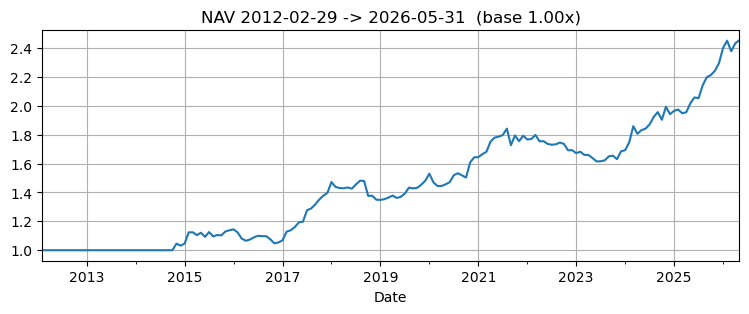

In [7]:
# Vista rápida del NAV (el 'sparkline' del panel NAV es esta misma curva)
eq.plot(figsize=(9, 3), title=f"NAV {returns.index[0].date()} -> {returns.index[-1].date()}  (base 1.00x)", grid=True);

### Checklist de la sección Overview
- [ ] Entiendo la señal: `binary` (signo) vs `strength` (continua normalizada), y el rol del **lookback** (12m).
- [ ] Entiendo la **vol ex-ante** (EWMA, com=3) y por qué normalizamos por riesgo (que todos aporten igual).
- [ ] Entiendo **`pooled`** (1/N global) vs **`class_balanced`** (presupuesto igual por clase) y por qué el default es `pooled`.
- [ ] Entiendo que el **NAV/KPIs** suman crash filter + vol-scaling de portafolio (no solo la señal cruda).
- [ ] Net exposure, # long/short y NAV del notebook coinciden con la terminal.

> **Próxima sección:** `02 · Backtest` — KPIs en detalle, curva neta vs bruta, drawdown, heatmap mensual y
> tabla de métricas. La armamos cuando termines de preguntar sobre el Overview.

---
# 02 · Backtest

La página **Backtest** responde la pregunta central del TP: **¿la estrategia hubiera funcionado?** Toma los
pesos del motor (`BacktestEngine` — los mismos que se operan en vivo en IBKR), los aplica mes a mes sobre los
retornos reales del universo, **descuenta costos** y resume el resultado. Tiene cinco bloques:

1. **KPIs** (tira de arriba) — Sharpe, retorno anualizado, volatilidad, max drawdown y Calmar.
2. **Curva de capital** (escala log) — el NAV **neto** vs el **bruto** (sin costos).
3. **Drawdown** — cuánto está la cartera por debajo de su máximo histórico (*underwater*).
4. **Tabla de métricas** — las mismas medidas + Sortino, hit rate, turnover y nº de meses.
5. **Heatmap de retornos mensuales** — cada mes coloreado (verde = ganancia, rojo = pérdida).

Lo recorremos en tres pasos: primero **de dónde sale cada retorno** (A), después **cómo se calcula cada
métrica** (B), y por último **qué dice cada gráfico** (C). Todos los números salen del mismo backend que el
dashboard.

## A. De dónde sale cada retorno: bruto, costos y neto

El motor (`src/backtest/engine.py`) arma la serie de retornos del portafolio en tres pasos:

**1) Retorno bruto** — la posición de cada activo por su retorno del mes, sumado sobre todo el universo:

$$r^{\text{bruto}}_t \;=\; \sum_i w_{i,t}\, r_{i,t}$$

Clave de *timing*: $w_{i,t}$ se decide con información **hasta $t-1$** (la señal lleva `shift(1)`) y recién
después gana el retorno del mes $t$. Así **no hay look-ahead bias**: nunca usás el dato del mes para decidir
la posición de ese mismo mes.

**2) Costos de transacción** — cada vez que cambiás los pesos pagás *spread* + comisión sobre lo que moviste
(`src/backtest/costs.py`):

$$\text{costo}_t \;=\; \underbrace{\sum_i \lvert\Delta w_{i,t}\rvert}_{\text{turnover}_t}\;\cdot\;\Big(\tfrac{\text{spread}}{2} + \text{comisión}\Big)$$

Vale la pena abrir **cada valor** de esa fórmula, porque cada uno modela un costo real distinto:

- **$\text{turnover}_t = \sum_i \lvert\Delta w_{i,t}\rvert$** — *cuánto rotó la cartera ese mes*: la suma de
  los cambios **absolutos** de peso, activo por activo. Si un ETF pasa de $0\% \to 5\%$ (comprás 5) y otro de
  $3\% \to 0\%$ (vendés 3), el turnover es $5\% + 3\% = 8\%$. Es la **base imponible** del costo: solo pagás
  por lo que efectivamente comprás o vendés, no por lo que dejás quieto. El valor absoluto hace que comprar y
  vender cuesten igual (los dos mueven mercado).

- **$\dfrac{\text{spread}}{2}$** — acá está el *"¿por qué dividido 2?"*. El **bid-ask spread** es la brecha
  entre el precio al que el mercado te **vende** (ask, más caro) y al que te **compra** (bid, más barato). El
  "precio justo" es el punto medio (*mid*). Cuando hacés **una** operación, no cruzás el spread entero: al
  comprar pagás medio spread por encima del mid, y al vender cobrás medio spread por debajo. Es decir, **una
  transacción cuesta la mitad del spread cotizado** → $\text{spread}/2$ (el costo *one-way*; el spread entero
  recién lo pagás si comprás *y* después vendés, *round-trip*). Con `bid_ask_spread = 10 bps` del `config`,
  eso es **5 bps** por operación.

- **$\text{comisión}$** — el fee del broker, como % del monto operado. A diferencia del spread, esto **no** se
  divide: lo cobran completo en cada trade. Con `commission_pct = 5 bps`, son **5 bps**.

- **Suma** → cada unidad de turnover cuesta $\tfrac{\text{spread}}{2} + \text{comisión} = 5 + 5 = \textbf{10
  bps}$ *one-way*. Más rebalanceo ⇒ más turnover ⇒ más costo: por eso vigilamos el turnover (y por eso una
  señal que *flipea* mucho, como `binary` en activos planos, es cara).

> **Supuestos del modelo (para ser honestos).** Es un modelo de costos **proporcional y lineal**: asume
> spread y comisión fijos para todos los ETF y todos los tamaños de orden. En la realidad el spread varía por
> liquidez y se *ensancha* en órdenes grandes (*market impact*), pero como operamos ETF líquidos con
> rebalanceo mensual, un costo plano de 10 bps one-way es una aproximación conservadora y estándar.

**3) Retorno neto** — lo que de verdad te queda:

$$r^{\text{neto}}_t \;=\; r^{\text{bruto}}_t - \text{costo}_t$$

> **Todas las métricas de performance se calculan sobre el retorno NETO.** La diferencia bruto − neto es el
> "peaje" de operar; la celda de abajo lo cuantifica.

In [ ]:
# Backtest COMPLETO (mismo motor que el dashboard y que la ejecución en vivo en IBKR)
res   = BacktestEngine(config).run(returns, use_signal_strength=(config['strategy']['signal_mode'] == 'strength'))
gross = res.gross_returns       # retorno mensual ANTES de costos
net   = res.portfolio_returns   # retorno mensual NETO (gross - costos)

tc = config['transaction_costs']
per_unit = tc['bid_ask_spread'] / 2 + tc['commission_pct']
print(f"Costo por unidad de turnover : spread/2 + comisión = "
      f"{tc['bid_ask_spread']/2*1e4:.0f} + {tc['commission_pct']*1e4:.0f} = {per_unit*1e4:.0f} bps (one-way)")
print(f"Turnover mensual promedio    : {res.weights.diff().abs().sum(axis=1).mean():.1%}")
print(f"Costo anual promedio (drag)  : {res.costs.mean()*12*100:.2f}%\n")
print(f"Ann. Return BRUTO  : {annualized_return(gross):+.2%}")
print(f"Ann. Return NETO   : {annualized_return(net):+.2%}")
print(f"Peaje de operar    : {(annualized_return(gross)-annualized_return(net))*100:.2f} pp por año")

## B. Las métricas de performance

Todas se calculan sobre el retorno **mensual neto** y se anualizan con factor $12$ (o $\sqrt{12}$ para los
desvíos). Convención del proyecto: **tasa libre de riesgo $rf = 0$** (estándar en la literatura de momentum, y
con las tasas bajas de buena parte del período cambia poco).

| Métrica | Fórmula | Qué dice |
|---|---|---|
| **Annualized Return** | $\big(\prod_t (1+r_t)\big)^{12/n} - 1$ | retorno compuesto por año |
| **Annualized Volatility** | $\operatorname{std}(r_t)\cdot\sqrt{12}$ | cuánto oscila por año (riesgo total) |
| **Sharpe Ratio** | $\dfrac{\overline{r}}{\operatorname{std}(r)}\cdot\sqrt{12}$ | retorno por unidad de **riesgo total** |
| **Sortino Ratio** | $\dfrac{\overline{r}}{\operatorname{std}(r_t\,<\,0)}\cdot\sqrt{12}$ | como Sharpe, pero castiga **solo las caídas** |
| **Max Drawdown** | $\min_t \dfrac{\text{NAV}_t - \max_{s\le t}\text{NAV}_s}{\max_{s\le t}\text{NAV}_s}$ | la peor caída pico-a-valle |
| **Calmar Ratio** | $\dfrac{\text{Ann. Return}}{\lvert\text{Max Drawdown}\rvert}$ | retorno por unidad de **peor caída** |
| **Hit Rate** | $\operatorname{mean}(r_t > 0)$ | % de meses ganadores |
| **Avg Monthly Turnover** | $\operatorname{mean}_t \sum_i \lvert\Delta w_{i,t}\rvert$ | cuánto rota la cartera por mes |

> **Sharpe vs Sortino vs Calmar** miran el riesgo de forma distinta: Sharpe usa *toda* la volatilidad (premia
> y castiga los movimientos hacia arriba y hacia abajo por igual); Sortino solo la volatilidad *a la baja* (lo
> que de verdad duele); y Calmar lo reduce al peor momento histórico (el max drawdown). Que **Sortino > Sharpe**
> indica que la cartera tiene más volatilidad "buena" (al alza) que "mala" (a la baja).

In [ ]:
# Tabla de MÉTRICAS DE PERFORMANCE — exactamente las que muestra el panel del dashboard
from src.backtest.metrics import sortino_ratio, hit_rate, turnover

r = res.portfolio_returns   # retorno mensual NETO
tabla = pd.DataFrame(
    {'valor': [
        f"{annualized_return(r):+.2%}",
        f"{annualized_volatility(r):.2%}",
        f"{sharpe_ratio(r):.2f}",
        f"{sortino_ratio(r):.2f}",
        f"{max_drawdown(r):.2%}",
        f"{calmar_ratio(r):.2f}",
        f"{hit_rate(r):.1%}",
        f"{turnover(res.weights):.1%}",
        f"{len(r)}",
    ]},
    index=['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Sortino Ratio',
           'Max Drawdown', 'Calmar Ratio', 'Hit Rate', 'Avg Monthly Turnover', 'Num Months'],
)
tabla.index.name = 'métrica'
tabla

## C. Qué dice cada gráfico

**Curva de capital (escala log).** El NAV (1.00× al inicio) compuesto en el tiempo, en **neto** (verde) vs
**bruto** (gris punteado). Va en **escala logarítmica** a propósito: en log, una pendiente constante =
**tasa de crecimiento constante**, y un +10% se ve igual de "alto" arrastrando \$1 que arrastrando \$2M. Sin
log, los últimos años aplastarían visualmente a los primeros. La brecha que se abre entre neto y bruto es el
**costo acumulado** de operar.

**Drawdown (underwater).** En cada mes, cuánto está el NAV **por debajo de su máximo histórico**:
$\text{dd}_t = (\text{NAV}_t - \max_{s\le t}\text{NAV}_s)\,/\,\max_{s\le t}\text{NAV}_s$. Siempre $\le 0$;
vuelve a $0$ cuando la cartera hace un nuevo máximo. El punto más profundo es el **Max Drawdown**. Sirve para
ver no solo *cuánto* se perdió, sino *cuánto tardó en recuperarse* (el ancho del valle).

**Heatmap de retornos mensuales.** Cada celda es el retorno de un mes (filas = años, columnas = meses),
coloreada verde (ganancia) / rojo (pérdida). De un vistazo se ven la consistencia, los meses malos
concentrados (las crisis aparecen como franjas rojas) y la estacionalidad.

In [ ]:
# Curva de capital en escala LOG: NAV neto (con costos) vs bruto (sin costos)
import matplotlib.pyplot as plt
cum_net   = (1 + res.portfolio_returns).cumprod()   # NAV neto (base 1.00x)
cum_gross = (1 + res.gross_returns).cumprod()        # NAV bruto (sin costos)

ax = cum_gross.plot(figsize=(9, 3.2), logy=True, color='gray', ls='--', lw=1.2,
                    label='Bruto (sin costos)')
cum_net.plot(ax=ax, logy=True, color='green', lw=2, label='Neto (con costos)')
ax.set_title('Curva de capital — escala log · neto vs bruto')
ax.set_ylabel('NAV (log, base 1.00x)'); ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

In [ ]:
# Drawdown (underwater %): cuánto está el NAV por debajo de su máximo histórico
dd = (cum_net - cum_net.cummax()) / cum_net.cummax()
ax = (dd * 100).plot(figsize=(9, 2.6), color='crimson', lw=1.2)
ax.fill_between(dd.index, dd.values * 100, 0, color='crimson', alpha=0.15)
ax.set_title(f'Drawdown (underwater %) · peor caída = {dd.min()*100:.1f}%')
ax.set_ylabel('%'); ax.grid(True, alpha=0.3)
plt.tight_layout()

In [ ]:
# Heatmap de retornos mensuales (mismo pivot que el panel 'RETORNOS MENSUALES')
r = res.portfolio_returns
piv = (pd.DataFrame({'year': r.index.year, 'month': r.index.month, 'ret': r.values})
         .pivot(index='year', columns='month', values='ret')
         .reindex(columns=range(1, 13)))
piv.columns = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
(piv * 100).style \
    .background_gradient(cmap='RdYlGn', axis=None, vmin=-8, vmax=8) \
    .format('{:.1f}', na_rep='·') \
    .set_caption('Retornos mensuales (%) · verde = ganancia, rojo = pérdida')

### Checklist de la sección Backtest
- [ ] Entiendo **bruto vs neto**: $r^{\text{bruto}}=\sum_i w_{i,t}\,r_{i,t}$, costo $=$ turnover $\times$ (spread/2 + comisión), neto $=$ bruto $-$ costo.
- [ ] Entiendo el *timing* `shift(1)` → **sin look-ahead** (la posición de $t$ se decide con datos hasta $t-1$).
- [ ] Sé qué mide cada métrica y por qué **Sharpe / Sortino / Calmar** ven el riesgo distinto.
- [ ] Entiendo por qué la curva va en **escala log** y qué es el **drawdown** (underwater).
- [ ] Los KPIs y la tabla del notebook coinciden con la terminal (mismo motor, retorno neto, rf = 0).

> **Próxima sección:** `03 · Robustness` — sensibilidad a lookback / costos / target-vol, walk-forward e
> in-sample vs out-of-sample. La armamos cuando termines de preguntar sobre el Backtest.

---
# 03 · Robustness

Un buen backtest no alcanza: hay que mostrar que el resultado **no es producto de la suerte** — ni de haber
acertado un parámetro, ni de un período particular, ni de mirar los mismos datos con que se calibró. La página
**Tests de Robustez** ataca esas tres dudas, una por pestaña:

1. **Sensibilidad paramétrica** (A) — ¿el Sharpe se cae si muevo el lookback, los costos o el target vol? Una
   estrategia robusta degrada *suave*; no tiene un óptimo "filo de cuchillo".
2. **Stress test** (B) — ¿cómo se comportó en las crisis (COVID 2020, shock de tasas 2022)?
3. **Out-of-sample** (C) — ¿sobrevive fuera de la muestra? Walk-forward (testear hacia adelante) e in-sample
   vs out-of-sample.

Todo sale del mismo backend (`src/robustness/*`), que **re-corre el motor real** en cada variante. Es la
sección que convierte "me dio buen Sharpe" en "el resultado es creíble".

## A. Sensibilidad paramétrica

La idea: re-correr el backtest cambiando **un** parámetro por vez y ver si el Sharpe aguanta. Si la estrategia
solo funciona en un punto exacto y se derrumba al lado, es *overfitting*; si degrada de a poco, es robusta.

- **Lookback** (`lookback_sensitivity`) — meses de tendencia que mira la señal `[3, 6, 9, 12, 18, 24]`. Lo
  esperable en TSMOM: flojo en horizontes muy cortos (ruido) y muy largos (señal vieja), mejor en la zona de
  **~9–18 meses** (el "sweet spot" de Moskowitz et al. 2012). Lo importante: que se mantenga **positivo en
  todo el rango**, no que clave un único valor.
- **Costos** (`cost_sensitivity`) — sube el spread bid-ask `[0, 10, 50, 100, 200] bps` y mide cuánto Sharpe
  cuesta. Sirve para ver a partir de qué costo la estrategia deja de rendir (nuestro supuesto real son 10 bps).
- **Target vol** (`target_vol_sensitivity`) — el riesgo objetivo *por activo* `[5%…20%]`. Como después actúa
  el vol-scaling del portafolio (objetivo 7%), mover este parámetro **casi no cambia el Sharpe** (reescala el
  apalancamiento, no la mezcla de señal) — y esa insensibilidad *también* es una forma de robustez.

> Cada fila re-corre el **backtest completo** con ese único cambio; el resto del config queda en el óptimo
> (lookback 17m · target vol 17%). Por eso el óptimo 17m no aparece en la grilla de lookback (que va de 3 a
> 24 en saltos fijos), pero los vecinos 12–18m muestran la meseta.

In [ ]:
# Sensibilidad paramétrica: re-corre el backtest cambiando UN parámetro por vez
from IPython.display import display
from src.robustness.sensitivity import lookback_sensitivity, cost_sensitivity, target_vol_sensitivity
import matplotlib.pyplot as plt

lb = lookback_sensitivity(returns, config)      # lookbacks [3,6,9,12,18,24]
cs = cost_sensitivity(returns, config)           # spreads [0, 10, 50, 100, 200] bps
tv = target_vol_sensitivity(returns, config)     # target vol [5%..20%]

print("Sharpe por LOOKBACK (meses) — resto del config en el óptimo:"); display(lb.round(3))
print("Sharpe vs COSTOS (spread bid-ask; nuestro supuesto real = 0.001 = 10 bps):"); display(cs.round(3))
print("Sensibilidad al TARGET VOL (riesgo objetivo por activo):"); display(tv.round(3))

ax = lb['sharpe'].plot(kind='bar', figsize=(8, 2.6),
        color=['green' if v >= 0 else 'crimson' for v in lb['sharpe']])
ax.set_title('Sharpe por lookback (resto en el óptimo)')
ax.set_xlabel('lookback (meses)'); ax.set_ylabel('Sharpe'); ax.axhline(0, color='gray', lw=0.8)
plt.tight_layout(); plt.show()

## B. Stress test — performance en crisis

Acá miramos cómo se portó la estrategia en ventanas de crisis conocidas (`CRISIS_PERIODS`): GFC 2008, Taper
2013, COVID 2020 y shock de tasas 2022. La pregunta del trend following: **¿defiende en los derrumbes?** (la
teoría dice que sí: en un bear market la señal se da vuelta a short y la cartera puede ganar mientras el
mercado cae — la "convexidad" del momentum).

> ⚠️ **Cobertura honesta.** La estrategia recién opera desde **2014-11** (warm-up de la señal, ver §02), así
> que **GFC 2008 y Taper 2013 quedan fuera** del período activo y no se reportan (sus ventanas están vacías).
> Quedan **COVID 2020** y **shock de tasas 2022**, que sí caen dentro de la muestra operada. Para cubrir 2008
> habría que conseguir historia de los ETF desde ~2005.

El panel de equity sombrea las crisis sobre la curva (escala log) y la tabla (`analyze_crisis_performance`) da
retorno, volatilidad, Sharpe y drawdown de cada ventana. *Spoiler honesto:* en COVID la estrategia aguantó
bien, pero **2022 fue un año duro** (bonos y acciones cayeron juntos y el cambio brusco de régimen le pegó al
trend following) — está bien mostrarlo, no todo tiene que dar verde.

In [ ]:
# Stress test: equity con crisis sombreadas + tabla de performance por crisis
from src.robustness.stress_test import analyze_crisis_performance, CRISIS_PERIODS
from src.backtest.engine import BacktestEngine

res = BacktestEngine(config).run(returns, use_signal_strength=(config['strategy']['signal_mode'] == 'strength'))
eq = (1 + res.portfolio_returns).cumprod()

ax = eq.plot(figsize=(9, 3.2), logy=True, color='green', lw=1.8)
ax.set_xlim(eq.index[0], eq.index[-1])
for name, (s, e) in CRISIS_PERIODS.items():
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    if e < eq.index[0]:          # crisis anterior a que la estrategia opere -> no se sombrea
        continue
    ax.axvspan(max(s, eq.index[0]), min(e, eq.index[-1]), color='red', alpha=0.12)
    ax.text(max(s, eq.index[0]), eq.max(), f" {name}", fontsize=7, color='gray', va='top')
ax.set_title('Equity curve (log) — crisis sombreadas'); ax.set_ylabel('NAV (log)')
ax.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()

print("Performance durante crisis (solo ventanas dentro del período activo, desde 2014-11):")
display(analyze_crisis_performance(res.portfolio_returns))

## C. Validación out-of-sample

El test más exigente: ¿la estrategia funciona en datos que *no* se usaron para mirarla? Dos enfoques
complementarios.

**Walk-forward** (`walk_forward`) — ventana móvil: entrena 5 años, **testea el año siguiente**, avanza 1 año y
repite. Cada barra es el Sharpe del año testeado (out-of-sample respecto de su ventana de entrenamiento). Lo
que buscamos: que la **mayoría** de las ventanas den Sharpe positivo, no que una sola salve el promedio.

**In-sample vs out-of-sample** (`expanding_window`) — parte la línea de tiempo: los primeros 36 meses
(*in-sample*) contra el resto (*out-of-sample*). Si el Sharpe OOS se desploma frente al IS, hay sobreajuste;
si se mantiene parecido, la estrategia generaliza.

> **Matiz importante (para la defensa).** El lookback y el target vol se eligieron optimizando el Sharpe sobre
> **toda** la muestra, así que estos tests no son 100% "ciegos": con los parámetros fijos, miden la
> estabilidad *temporal*, no una re-optimización en cada ventana. Aun así, un OOS que se sostiene cerca del IS
> es buena señal de que no estamos sobreajustando. La señal en sí nunca usa el futuro (el `shift(1)` lo
> garantiza, §02).

In [ ]:
# Out-of-sample: walk-forward (ventana móvil) + in-sample vs out-of-sample
from src.robustness.out_of_sample import walk_forward, expanding_window

wf = walk_forward(returns, config)
ax = wf.set_index('test_start')['sharpe'].plot(
        kind='bar', figsize=(9, 2.8),
        color=['green' if v >= 0 else 'crimson' for v in wf['sharpe']])
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Walk-forward — Sharpe out-of-sample por ventana anual')
ax.set_xlabel('inicio del test'); ax.set_ylabel('Sharpe')
plt.tight_layout(); plt.show()

print("Walk-forward (detalle por ventana — entrena 5a, testea el año siguiente):")
display(wf.round(2))
print("\nIn-sample (primeros 36m) vs Out-of-sample (resto):")
display(expanding_window(returns, config).round(2))

### Checklist de la sección Robustness
- [ ] Entiendo la **sensibilidad**: re-correr cambiando un parámetro y ver que el Sharpe degrada *suave* (no "filo de cuchillo").
- [ ] Sé por qué el **target vol casi no mueve el Sharpe** (lo domina el vol-scaling del portafolio al 7%).
- [ ] Entiendo el **stress test** y por qué solo se reportan **COVID 2020** y **shock de tasas 2022** (la estrategia opera desde 2014-11).
- [ ] Distingo **walk-forward** (testeo hacia adelante, ventana móvil) de **in-sample vs out-of-sample** (split temporal).
- [ ] Tengo claro el matiz: los parámetros se optimizaron sobre **toda** la muestra → los tests miden estabilidad, con un sesgo IS residual.

> **Próxima sección:** `04 · Live Portfolio` — conexión a IBKR paper, ciclo de vida de la estrategia,
> rebalanceo mensual en vivo, drift y kill switch. La armamos cuando termines de preguntar sobre Robustness.